# Explorartory Data Analysis

1. Importing modeules

In [11]:
import psycopg2 
import pandas as pd
import yaml
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

2. Getting config's from yaml

In [2]:
yaml_file_path = '../config/config.yaml'
with open(yaml_file_path) as file:
    config = yaml.safe_load(file)

3. Opening Connection with Database

In [3]:
db_con = config['database']

conn = psycopg2.connect(
    host= db_con['host'],
    port= db_con['port'],
    user= db_con['username'],
    password= db_con['password'],
    dbname= db_con['name']
)

cur = conn.cursor()

4. Getting data from Database

In [4]:
query = """
        SELECT * FROM weather;
        """

try:
    cur.execute(query)
    data = cur.fetchall()
    columns = [desc[0] for desc in cur.description]
except Exception as e:
    print(f"-- {datetime.now()} - {e}")
finally:
    cur.close()
    conn.close()

5. Creating a DataFrame

In [26]:
df = pd.DataFrame(data, columns=columns)
df.head()

,id,date,name,description,temp,feels_like,temp_min,temp_max,humidity,sunrise,sunset,wind_speed
0,1,2026-03-13,Berlin,Clear,12.44,11.36,11.01,12.82,62,2026-03-14,2026-03-14,3.60
1,2,2026-03-13,Hamburg,Rain,4.84,4.84,4.33,6.26,89,2026-03-14,2026-03-14,1.03
2,3,2026-03-13,Munich,Clouds,4.31,4.31,2.52,4.58,87,2026-03-14,2026-03-14,0.45
3,4,2026-03-13,Cologne,Rain,4.36,3.16,4.03,4.97,91,2026-03-14,2026-03-14,1.54
4,5,2026-03-13,Frankfurt am Main,Rain,11.19,10.48,10.19,12.16,81,2026-03-14,2026-03-14,5.66


6. Exploring Data Analysis

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           53 non-null     int64         
 1   date         53 non-null     datetime64[us]
 2   name         53 non-null     str           
 3   description  53 non-null     str           
 4   temp         53 non-null     float64       
 5   feels_like   53 non-null     float64       
 6   temp_min     53 non-null     float64       
 7   temp_max     53 non-null     float64       
 8   humidity     53 non-null     int64         
 9   sunrise      53 non-null     datetime64[us]
 10  sunset       53 non-null     datetime64[us]
 11  wind_speed   53 non-null     float64       
dtypes: datetime64[us](3), float64(5), int64(2), str(2)
memory usage: 5.1 KB


In [44]:
df.describe()

,id,date,temp,feels_like,temp_min,temp_max,humidity,sunrise,sunset,wind_speed
count,53.000000,53,53.000000,53.000000,53.000000,53.000000,53.000000,53,53,53.000000
mean,27.000000,2026-03-13 00:00:00,6.933774,5.650755,6.251698,7.609434,84.849057,2026-03-14 00:00:00,2026-03-14 00:00:00,2.603962
min,1.000000,2026-03-13 00:00:00,2.800000,1.390000,2.520000,3.110000,55.000000,2026-03-14 00:00:00,2026-03-14 00:00:00,0.450000
25%,14.000000,2026-03-13 00:00:00,4.360000,2.800000,3.790000,4.970000,77.000000,2026-03-14 00:00:00,2026-03-14 00:00:00,1.340000
50%,27.000000,2026-03-13 00:00:00,5.120000,3.960000,4.490000,5.820000,91.000000,2026-03-14 00:00:00,2026-03-14 00:00:00,2.570000
75%,40.000000,2026-03-13 00:00:00,11.190000,10.260000,10.090000,11.720000,93.000000,2026-03-14 00:00:00,2026-03-14 00:00:00,3.090000
max,53.000000,2026-03-13 00:00:00,12.910000,11.880000,11.720000,13.050000,100.000000,2026-03-14 00:00:00,2026-03-14 00:00:00,8.490000
std,15.443445,NaN,3.392282,3.612866,3.247646,3.374297,12.599445,NaN,NaN,1.775004


In [7]:
df.columns

Index(['id', 'date', 'name', 'description', 'temp', 'feels_like', 'temp_min',
       'temp_max', 'humidity', 'sunrise', 'sunset', 'wind_speed'],
      dtype='str')

7. Distribution of each Metric

In [8]:
list_numeric_cols = df.select_dtypes(np.int64).columns.to_list() + df.select_dtypes(np.float64).columns.to_list()

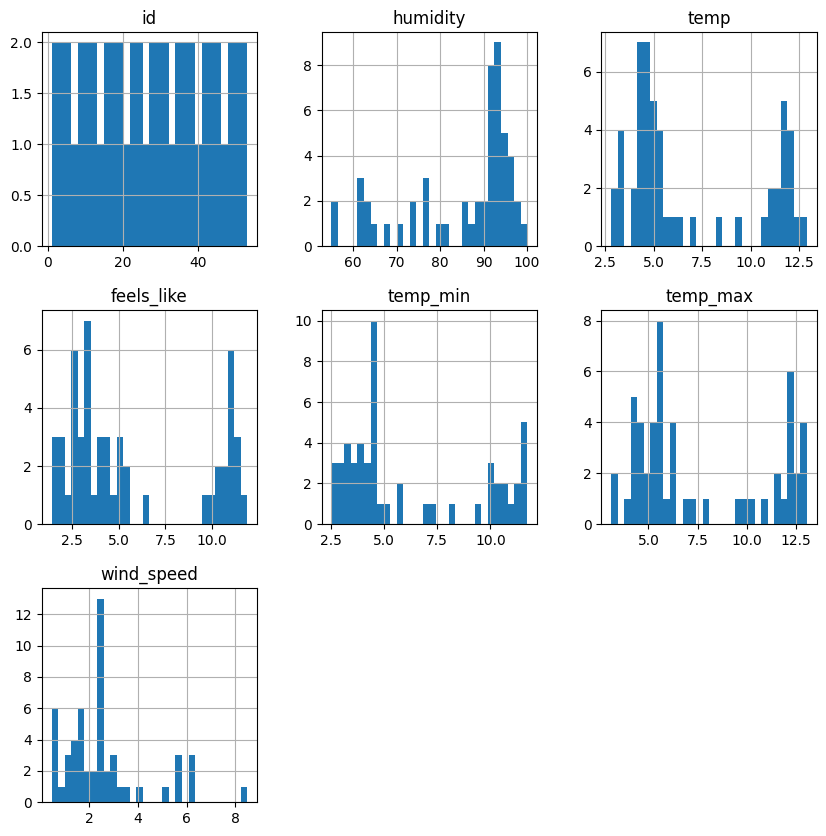

In [13]:
df[list_numeric_cols].hist(bins=30, figsize=(10,10))
plt.show()

8. Compare Cities

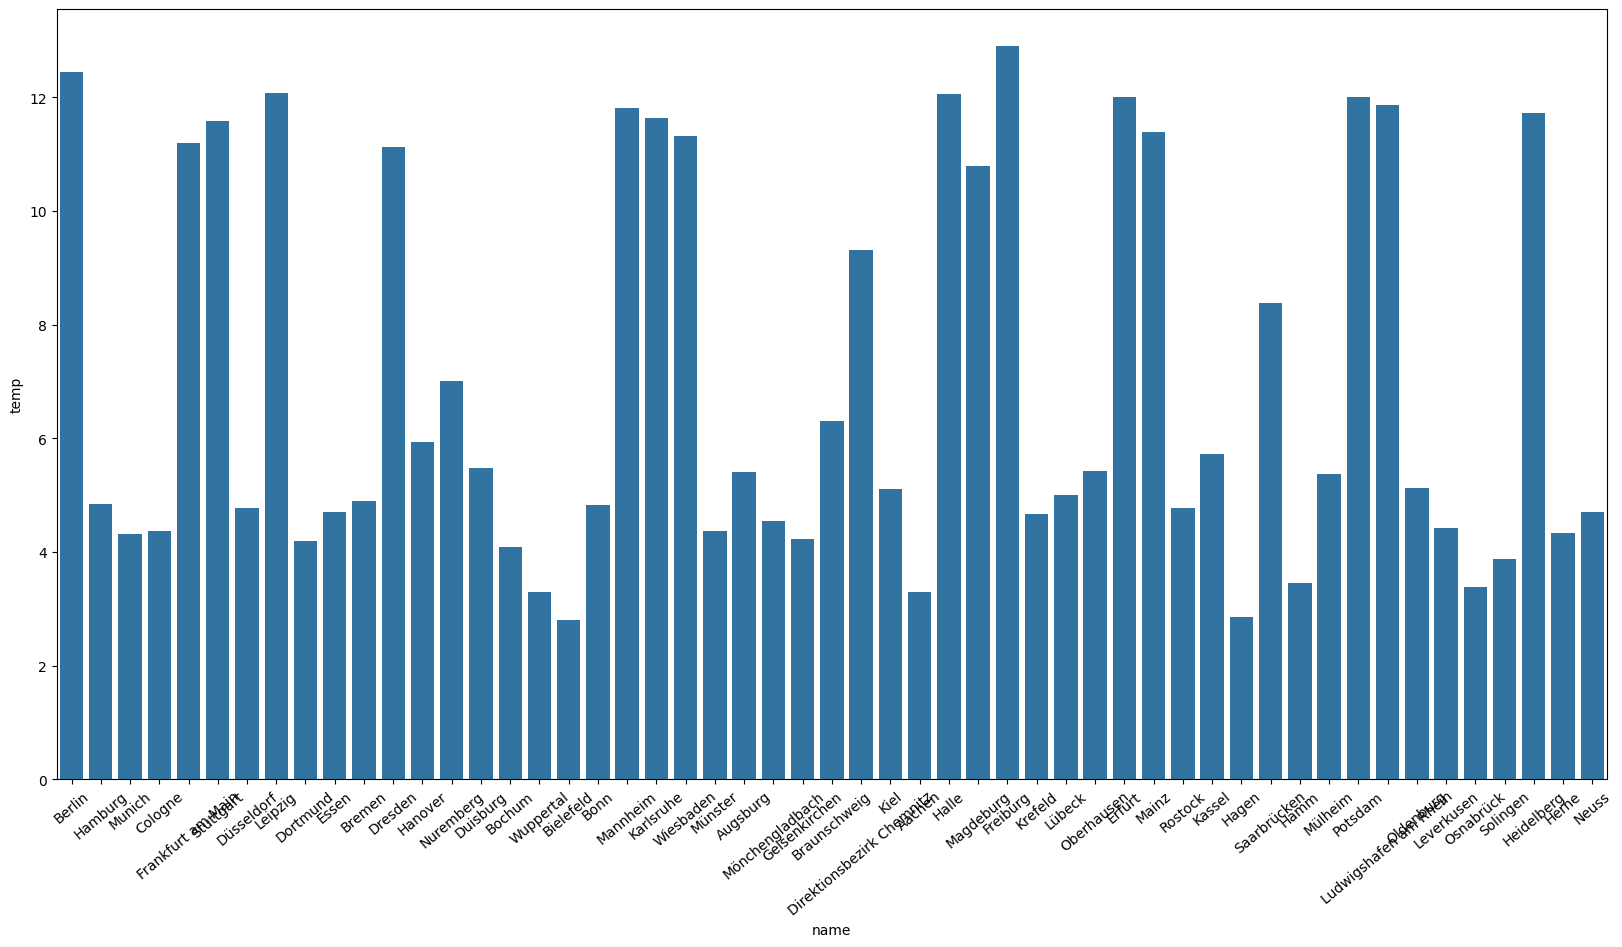

In [19]:
plt.figure(figsize=(20,10))
sns.barplot(x='name', y='temp', data=df)
plt.xticks(rotation=40)
plt.show()

9. Corelation

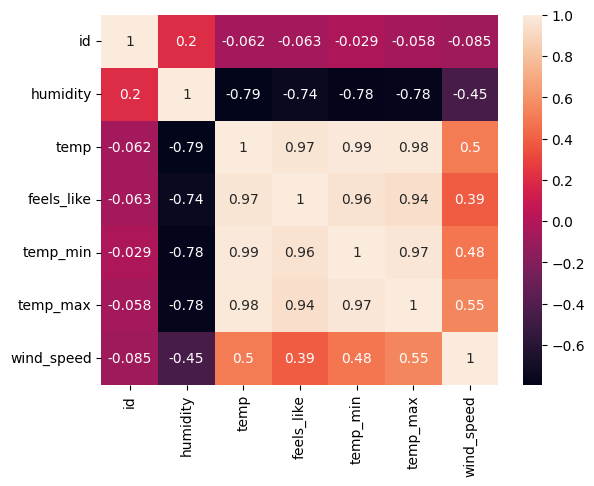

In [21]:
sns.heatmap(df[list_numeric_cols].corr(), annot=True)
plt.show()

10. Getting Highest Lowest Temp

In [24]:
print(df.nlargest(1, 'temp')[['name', 'temp']])
print(df.nsmallest(1, 'temp')[['name', 'temp']])
print(df.nlargest(1, 'humidity')[['name', 'humidity']])

        name   temp
32  Freiburg  12.91
         name  temp
17  Bielefeld   2.8
      name  humidity
34  Lübeck       100
